<center>

<table>
<tr><td align="center">
<img src="https://raw.githubusercontent.com/Robel-ermiyas/Spam-Email-Detection/main/Logo2.jpg" width="120">
</td></tr>
<tr><td align="center"><br>
<h1><b>Addis Ababa Science and Technology University</b></h1>
<h2><b> College of Engineering</h2>
<h3><b> Department of Software Engineering </h3>
</td></tr>
</table>

<!-- <hr> -->
<br>
<hr width="75%">

<!-- <table align="center" width="70%" style="background:#eef2ff; border:2px solid #c7d2fe;"> -->
</td></tr>
<tr><td align="center"><br>
<h4> <b>MACHINE LEARNING GROUP PROJECT</b></h4>
<h4> <b>FLOWER SPECIES CLASSIFIER USING DEEP LEARNING</b></h2>
<br>
</td></tr>
</table>
<hr width="75%">

<center>



<table width="100%" align="center">
<tr><td align="center">

<table style="border-collapse:collapse;">
<tr><td align="right">1.</td><td>&nbsp;</td><td align="left">Samir Nafie</td><td>&nbsp;....&nbsp;</td><td align="left">ETS1189/15</td></tr>
<tr><td align="right">2.</td><td>&nbsp;</td><td align="left">Samuel Birhanu</td><td>&nbsp;....&nbsp;</td><td align="left">ETS1207/15</td></tr>
<tr><td align="right">3.</td><td>&nbsp;</td><td align="left">Yohannes Gezahegn</td><td>&nbsp;....&nbsp;</td><td align="left">ETS1437/15</td></tr>
<tr><td align="right">4.</td><td>&nbsp;</td><td align="left">Yabets Alelign</td><td>&nbsp;....&nbsp;</td><td align="left">ETS1352/15</td></tr>
<tr><td align="right">5.</td><td>&nbsp;</td><td align="left">Suad Abrar</td><td>&nbsp;....&nbsp;</td><td align="left">ETS1299/15</td></tr>
<tr><td align="right">6.</td><td>&nbsp;</td><td align="left">Tekta Tewodros</td><td>&nbsp;....&nbsp;</td><td align="left">ETS1278/15</td></tr>
</table>

</td></tr>
</table>

</center>

<br>

<table align="right" width="60%" style="border:2px solid #bbf7d0;">
<tr><td align="center"><br>
<p><b>Instructor: </b>Fedlu N.</p>
<p><b>Date:</b> JUNE 2026</p>
<br>
</td></tr>
</table>

<br>

</center>

### 1. Initial Setup: TensorFlow Version and GPU Check

This cell initializes the environment by importing the TensorFlow library and then prints its version. It also checks for the availability and configuration of a GPU. Utilizing a GPU significantly speeds up deep learning computations, which is crucial for training complex models efficiently.

In [3]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2. Install TensorFlow Datasets

This command ensures that the `tensorflow-datasets` library is installed in the environment. This library provides a wide range of pre-prepared datasets, making it easier to load and use data for machine learning tasks without manual data collection and preprocessing.

In [4]:
!pip install tensorflow-datasets

### 3. Import Necessary Libraries

This cell imports all the required Python libraries for this notebook:
- `tensorflow` (`tf`): The core library for building and training machine learning models.
- `tensorflow_datasets` (`tfds`): Used for easily loading and accessing datasets.
- `matplotlib.pyplot` (`plt`): For creating static, animated, and interactive visualizations.
- `numpy` (`np`): For numerical operations, especially with arrays and matrices.

In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

### 4. Load the 'tf_flowers' Dataset

This code block loads the 'tf_flowers' dataset. It splits the dataset into 80% for training (`ds_train`) and 20% for testing (`ds_test`). The `as_supervised=True` argument ensures that the data is loaded as (image, label) pairs, and `with_info=True` retrieves metadata about the dataset, such as class names and number of examples.

In [6]:
(ds_train, ds_test), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.Z26NKA_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


### 5. Retrieve Class Names

After loading the dataset, this cell extracts the human-readable names of the flower classes (e.g., 'dandelion', 'roses') from the `ds_info` object. These names are essential for understanding and interpreting the model's predictions.

In [7]:
class_names = ds_info.features['label'].names

print(class_names)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


### 6. Display Dataset Statistics

This cell prints key statistics about the dataset: the total number of distinct flower classes and the number of samples available in the training set. This gives a quick overview of the dataset's size and complexity.

In [8]:
print("Number of classes:", len(class_names))
print("Training samples:", ds_info.splits['train'].num_examples)

Number of classes: 5
Training samples: 3670


### 7. Visualize a Single Image from the Training Set

This code block takes one sample (an image and its corresponding label) from the `ds_train` dataset. It then prints the image's shape and its class name, and finally displays the image using `matplotlib`. This helps to verify the data loading and label association.

Image Shape: (333, 500, 3)
Label: tulips


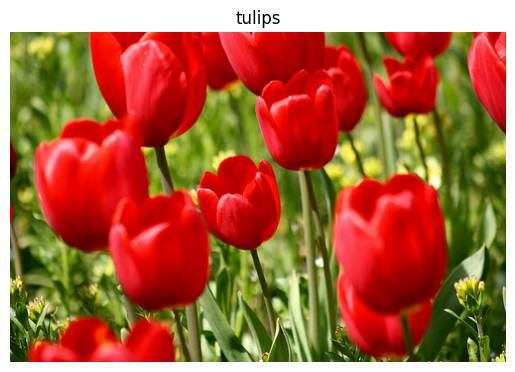

In [9]:
for image, label in ds_train.take(1):
    print("Image Shape:", image.shape)
    print("Label:", class_names[label])

    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

### 8. Visualize Multiple Images from the Training Set

To get a broader sense of the dataset, this cell displays a grid of 9 sample images from the training set. Each image is shown with its respective class label, allowing for a visual inspection of the diversity within the dataset.

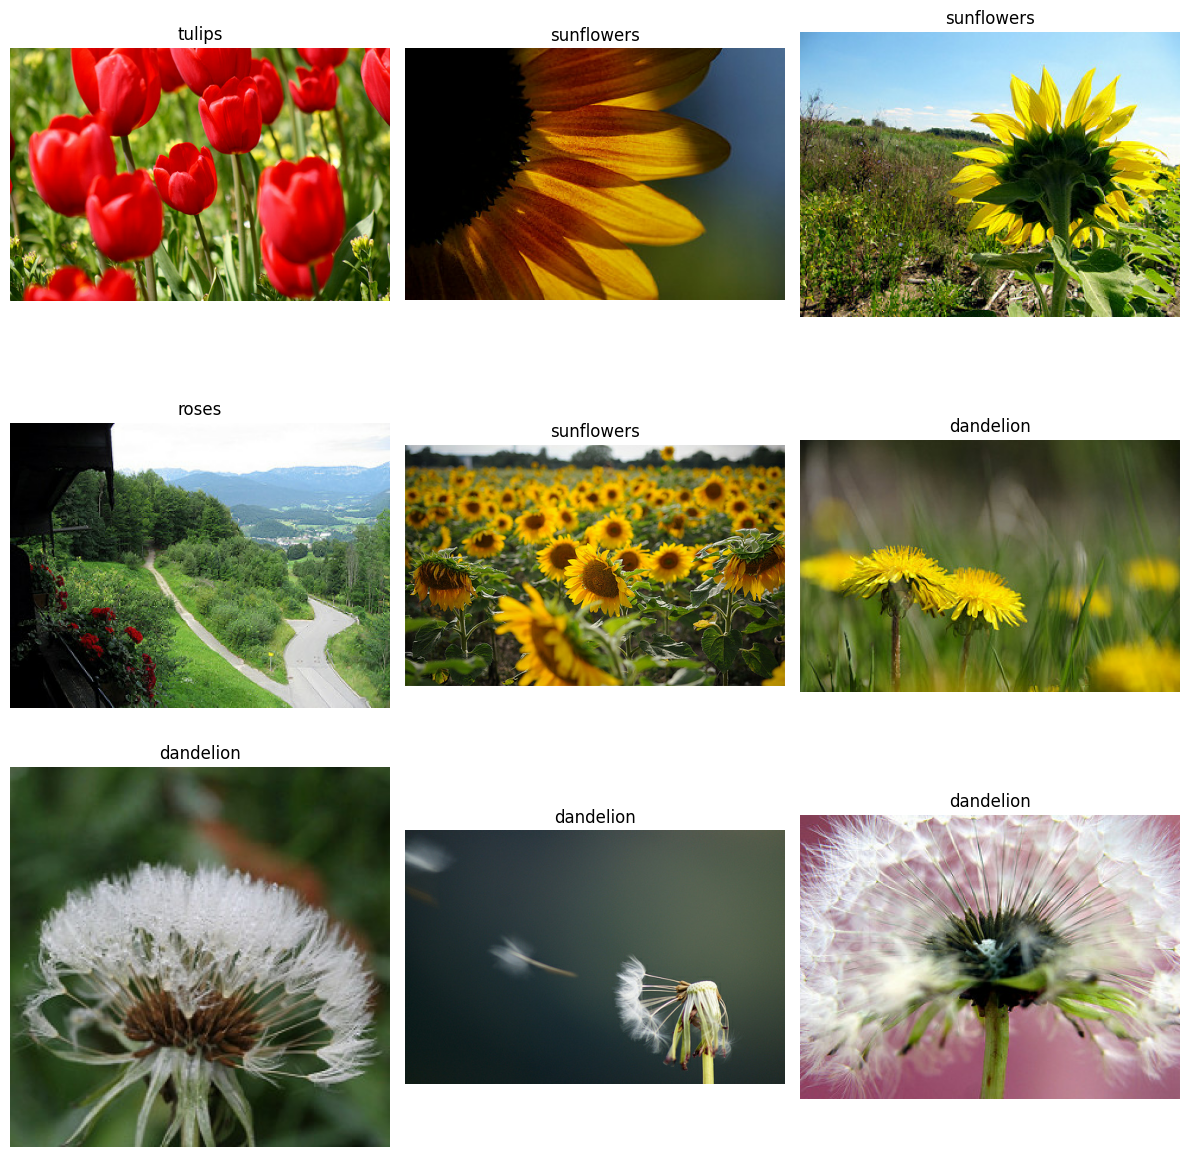

In [10]:
plt.figure(figsize=(12, 12))

for i, (image, label) in enumerate(ds_train.take(9)):
    plt.subplot(3, 3, i + 1)

    plt.imshow(image)
    plt.title(class_names[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

### 9. Define Image Size for Preprocessing

This cell sets a global constant `IMG_SIZE` to 224 pixels. This size will be used to resize all input images to a uniform dimension (224x224 pixels) during the preprocessing step. Consistent image dimensions are required for input into convolutional neural networks.

In [11]:
IMG_SIZE = 224

### 10. Image Preprocessing Function

This `preprocess` function is defined to prepare images for model training:
1.  **Resize Image:** `tf.image.resize` rescales the image to the predefined `IMG_SIZE` (224x224 pixels).
2.  **Normalize Pixel Values:** The pixel values are divided by 255.0 to scale them from the original 0-255 range to a 0-1 range. This normalization is a standard practice in deep learning to improve model performance and training stability.

In [12]:
def preprocess(image, label):

    # Resize image
    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # Normalize pixel values
    image = image / 255.0

    return image, label

### 11. Apply Preprocessing to Datasets

This cell applies the `preprocess` function to every image in both the training (`ds_train`) and testing (`ds_test`) datasets using the `map` function. This transforms all images to the required size and normalizes their pixel values.

In [13]:
train_ds = ds_train.map(preprocess)

test_ds = ds_test.map(preprocess)

### 12. Inspect the Preprocessed Training Dataset

This cell prints the `element_spec` of the `ds_train` dataset after preprocessing. The `element_spec` describes the structure, data types, and shapes of the elements within the dataset, confirming that the preprocessing steps were applied correctly (e.g., images are now (224, 224, 3) and float32).

In [14]:
print(ds_train)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


### 13. Inspect Preprocessed Image Pixel Values

This code block takes one sample from the preprocessed `train_ds` to verify the pixel value range. It prints the minimum and maximum pixel values, which should be 0.0 and 1.0 respectively, confirming successful normalization.

In [15]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [16]:
(ds_train, ds_test), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

In [17]:
IMG_SIZE = 224

In [18]:
def preprocess(image, label):

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image / 255.0

    return image, label

In [19]:
train_ds = ds_train.map(preprocess)
test_ds = ds_test.map(preprocess)

In [20]:
for image, label in train_ds.take(1):

    print("Shape:", image.shape)

    print("Min Pixel:", tf.reduce_min(image).numpy())

    print("Max Pixel:", tf.reduce_max(image).numpy())

Shape: (224, 224, 3)
Min Pixel: 0.0
Max Pixel: 1.0


### 14. Batch the Datasets

This cell defines `BATCH_SIZE` as 32 and then applies batching to both the training and testing datasets. Batching groups multiple data samples together, which is crucial for efficient training of neural networks on GPUs. The model processes data in these batches rather than one sample at a time.

In [21]:
BATCH_SIZE = 32

train_ds = train_ds.batch(BATCH_SIZE)

test_ds = test_ds.batch(BATCH_SIZE)

### 15. Prefetch Datasets for Performance Optimization

This cell applies the `prefetch` transformation to both the batched training and testing datasets. `tf.data.AUTOTUNE` automatically determines the optimal number of elements to prefetch. This technique overlaps the data preprocessing and model execution steps, ensuring that the GPU is continuously fed with data and preventing bottlenecks during training.

In [22]:
train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

test_ds = test_ds.prefetch(
    tf.data.AUTOTUNE
)

### 16. Inspect Batched Image and Label Shapes

This cell takes one batch from the `train_ds` and prints the shapes of the image batch and the label batch. This step confirms that the data pipeline is producing batches with the expected dimensions: `(BATCH_SIZE, IMG_SIZE, IMG_SIZE, 3)` for images and `(BATCH_SIZE,)` for labels.

In [23]:
for images, labels in train_ds.take(1):

    print("Images Shape:", images.shape)

    print("Labels Shape:", labels.shape)

Images Shape: (32, 224, 224, 3)
Labels Shape: (32,)


### 17. Load Pre-trained EfficientNetB0 Base Model

This cell loads a pre-trained `EfficientNetB0` model from `tf.keras.applications`. `include_top=False` means that the classification head of the original model is excluded, allowing us to add our own custom classification layers. `weights='imagenet'` initializes the model with weights pre-trained on the ImageNet dataset, and `input_shape` matches our preprocessed image dimensions.

In [24]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 18. Freeze the Base Model Layers

By setting `base_model.trainable = False`, we freeze the weights of the pre-trained EfficientNetB0 model. This prevents their weights from being updated during the training of our custom layers, effectively using the base model as a fixed feature extractor. This is a common practice in transfer learning to leverage powerful pre-trained features without overwriting them.

In [25]:
print(tf.__version__)

2.20.0


In [26]:
base_model.trainable = False

### 19. Verify Base Model Trainability Status

This cell prints the `trainable` status of the `base_model` to confirm that its layers are indeed frozen. This ensures that only the newly added classification layers will be trained, saving computational resources and potentially preventing overfitting on smaller datasets.

In [27]:
print("Trainable:", base_model.trainable)

Trainable: False


### 20. Build the Custom Classification Model

This cell constructs the full classification model using `tf.keras.Sequential`. It stacks the following layers:
- `base_model`: The frozen EfficientNetB0 feature extractor.
- `tf.keras.layers.GlobalAveragePooling2D()`: Reduces the spatial dimensions of the features, preparing them for dense layers.
- `tf.keras.layers.Dense(128, activation='relu')`: A fully connected hidden layer with 128 neurons and ReLU activation.
- `tf.keras.layers.Dropout(0.3)`: A dropout layer that randomly sets 30% of input units to 0 during training, helping to prevent overfitting.
- `tf.keras.layers.Dense(len(class_names), activation='softmax')`: The final output layer with `len(class_names)` neurons (one for each flower species) and softmax activation for multi-class probability distribution.

In [28]:
model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

### 21. Display Model Summary

This cell prints a detailed summary of the entire custom model's architecture. It lists each layer, its output shape, and the number of trainable and non-trainable parameters. This summary is crucial for understanding the model's structure and complexity.

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 22. Print Model Output Shape

This cell displays the expected output shape of the model's final layer. For a classification model, this will typically be `(None, num_classes)`, where 'None' represents the batch size (which can vary) and `num_classes` is the number of distinct categories the model predicts.

In [30]:
print(model.output_shape)

(None, 5)


### 23. Compile the Model

Before training, the model must be compiled. This cell configures the training process with:
- `optimizer='adam'`: The Adam optimizer, a popular and effective optimization algorithm.
- `loss='sparse_categorical_crossentropy'`: The loss function suitable for multi-class classification problems when labels are integers (not one-hot encoded).
- `metrics=['accuracy']`: The metric to monitor during training and evaluation, indicating the proportion of correctly classified samples.

In [31]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 24. Train the Model

This cell initiates the training of the compiled model. The `model.fit()` method trains the model on the `train_ds` (training dataset) and evaluates its performance on the `test_ds` (validation dataset) after each epoch. The training runs for `epochs=10`, and the `history` object records metrics like loss and accuracy throughout the training process.

In [34]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.2517 - loss: 1.6010 - val_accuracy: 0.2166 - val_loss: 1.6044
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.2517 - loss: 1.6007 - val_accuracy: 0.2166 - val_loss: 1.6046
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.2517 - loss: 1.6000 - val_accuracy: 0.2166 - val_loss: 1.6053
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.2517 - loss: 1.6001 - val_accuracy: 0.2166 - val_loss: 1.6038
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.2517 - loss: 1.6001 - val_accuracy: 0.2166 - val_loss: 1.6040
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.2517 - loss: 1.6006 - val_accuracy: 0.2166 - val_loss: 1.6038
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.2517 - loss: 1.6001 - val_accuracy: 0.2166 - val_loss: 1.6039
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.2517 - loss: 1.5999 - val_accuracy: 0.2166 - v

### 25. Training Completion Message

This simple cell prints a confirmation message, indicating that the model training process has successfully concluded after the specified number of epochs.

In [33]:
print("Training Complete")

Training Complete


### 26. Model Summary (Post-Training)

This cell displays the model summary again after training. It's good practice to review the architecture and parameter counts to ensure everything remained as expected throughout the training phase, especially regarding trainable vs. non-trainable parameters.

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,543,412 (17.33 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 329,228 (1.26 MB)

### 27. Print Number of Classes (Verification)

This cell simply prints the total number of distinct classes (`len(class_names)`) that the model is trained to classify. This serves as a quick verification that the output layer of the model has the correct number of neurons.

In [36]:
print(len(class_names))

5


### 28. Inspect Shapes of Batched Data (Verification)

This cell takes one batch of images and labels from the `train_ds` and prints their shapes. This is a crucial step to ensure that the data pipeline is delivering data in the exact format (batch size, image dimensions, color channels, and batch size for labels) that the model expects as input.

In [37]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


### 29. Plot Training and Validation Accuracy

This cell generates a line plot to visualize the model's accuracy during training. It displays both the 'Training Accuracy' and 'Validation Accuracy' over the epochs. This plot is essential for diagnosing model performance: a widening gap between the two might indicate overfitting, while both staying low could suggest underfitting.

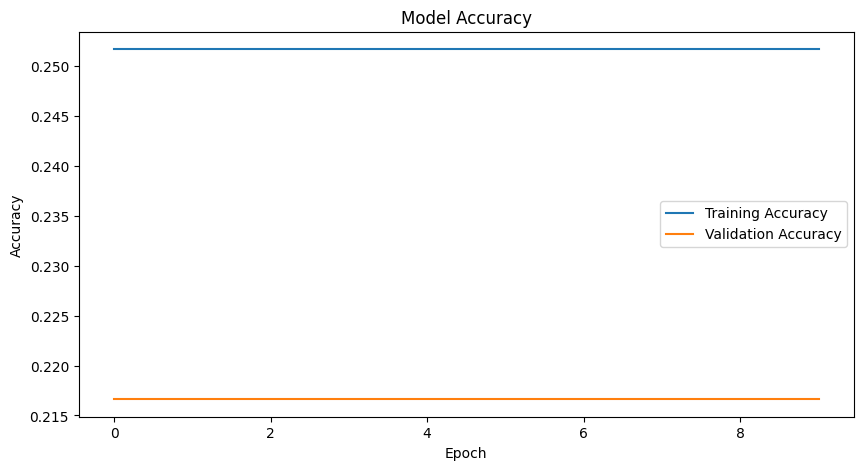

In [38]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### 30. Plot Training and Validation Loss

Similar to the accuracy plot, this cell creates a line plot showing the 'Training Loss' and 'Validation Loss' across the training epochs. The loss curves provide insight into how well the model is learning and generalizing. A decreasing validation loss indicates good learning, while an increasing validation loss (after initial decrease) often points to overfitting.

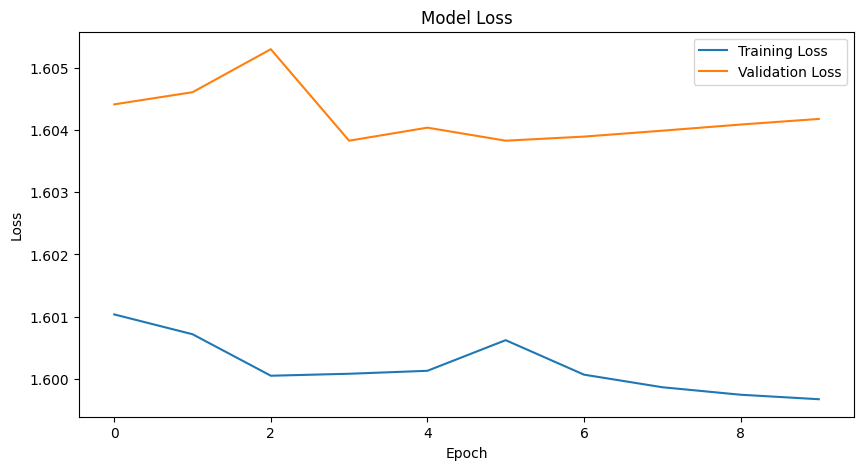

In [39]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 31. Evaluate Model on Test Dataset

After training, this cell evaluates the model's performance on the `test_ds` (the unseen test dataset). It computes and prints the final `Test Accuracy` and `Test Loss`. These metrics are the most reliable indicators of how well the model is expected to perform on new, real-world data.

In [40]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2166 - loss: 1.6042
Test Accuracy: 0.2166212499141693
Test Loss: 1.604183316230774


### 32. Save the Trained Model

This cell saves the trained Keras model to a file named `flower_classifier.keras`. Saving the model allows it to be easily reloaded later for inference, deployment, or further fine-tuning, without needing to retrain it from scratch. The `.keras` format is a universal standard for Keras models.

In [41]:
IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

In [42]:
train_ds = ds_train.map(preprocess)
test_ds = ds_test.map(preprocess)

train_ds = train_ds.batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [43]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False

In [44]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [45]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 282ms/step - accuracy: 0.8311 - loss: 0.4666 - val_accuracy: 0.9237 - val_loss: 0.2246
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9264 - loss: 0.1998 - val_accuracy: 0.9360 - val_loss: 0.1882
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9574 - loss: 0.1351 - val_accuracy: 0.9387 - val_loss: 0.1726
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9673 - loss: 0.1054 - val_accuracy: 0.9455 - val_loss: 0.1559
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9809 - loss: 0.0713 - val_accuracy: 0.9401 - val_loss: 0.1555
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9816 - loss: 0.0601 - val_accuracy: 0.9414 - val_loss: 0.1590
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9884 - loss: 0.0455 - val_accuracy: 0.9441 - val_loss: 0.1588
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9908 - loss: 0.0378 - val_accuracy: 0.9428 -

In [47]:
model.save("flower_classifier.keras")

### 33. Verify Saved Model Existence

This cell uses the `os.path.exists()` function to check if the `flower_classifier.keras` file has been successfully created and saved in the current directory. This confirms that the model saving operation was successful.

In [48]:
import os

print(os.path.exists("flower_classifier.keras"))

True


### 34. Download the Saved Model

This cell leverages `google.colab.files` to provide a convenient way to download the `flower_classifier.keras` model file from the Colab environment to your local machine. This is useful for archiving your trained model or deploying it elsewhere.

In [49]:
from google.colab import files

files.download("flower_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 35. List Files in Current Directory

This shell command (`!ls -lh`) lists all files in the current working directory, along with their sizes and permissions. This is useful for verifying that the `flower_classifier.keras` file was indeed saved and to check its size.

In [50]:
!ls -lh

total 19M
-rw-r--r-- 1 root root  19M Jun  2 14:55 flower_classifier.keras
drwxr-xr-x 1 root root 4.0K May 26 13:31 sample_data


### 36. Load the Trained Model

This cell demonstrates how to load a previously saved Keras model using `tf.keras.models.load_model()`. It loads the `flower_classifier.keras` file back into memory, making the trained model ready for prediction or further evaluation. A confirmation message is printed once the model is loaded.

In [51]:
loaded_model = tf.keras.models.load_model(
    "flower_classifier.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully
